# 🌐 Functional Tests / End-to-End Testing
## Demo en Vivo + Ejercicio de Cierre (15 min)

**Curso:** Pruebas de Software · 7mo Semestre  
**Herramienta:** Python + Playwright  
**App objetivo:** [TodoMVC](https://demo.playwright.dev/todomvc) — app pública diseñada para practicar E2E  
**Valle del Software**

---

### ¿Qué vamos a hacer?

| Sección | Contenido | Tiempo |
|---------|-----------|--------|
| 🔧 Setup | Instalar Playwright en Colab | 3 min |
| 🎬 Demo 1 | Navegar, encontrar elementos, hacer assertions | 5 min |
| 🏗️ Demo 2 | Page Object Model (POM) | 5 min |
| 🎭 Demo 3 | Flujo completo: crear, completar, eliminar tarea | 5 min |
| 🎯 Ejercicio | Tu turno — 15 minutos | 15 min |

> 💡 En Colab corremos en modo **headless** (sin ventana visible). Capturas de pantalla automáticas muestran el resultado.

---
## ⚙️ Setup — Instalar Playwright

In [ ]:
# Instalar Playwright y sus dependencias para Colab
!pip install playwright pytest-playwright --quiet
!playwright install chromium --with-deps

print('✅ Playwright instalado y listo.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 MB 19.6 MB/s eta 0:00:00
Installing dependencies...
Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [88.5 kB]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Hit:8 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy/main amd64 Packages [38.8 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.0 MB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-backp

In [ ]:
# Imports y utilidad para mostrar screenshots en el notebook
from playwright.async_api import async_playwright, Page, expect
from IPython.display import Image, display
import re

# URL de la app de práctica (TodoMVC — Playwright oficial)
TODO_URL = 'https://demo.playwright.dev/todomvc'

async def screenshot(page: Page, filename: str, title: str = ''):
    """Captura la pantalla y la muestra en el notebook."""
    path = f'/tmp/{filename}.png'
    await page.screenshot(path=path, full_page=False)
    if title:
        print(f'📸 {title}')
    display(Image(path, width=700))

print('✅ Imports listos. App objetivo:', TODO_URL)

✅ Tarea "Mi nueva tarea con locator" agregada y verificada.


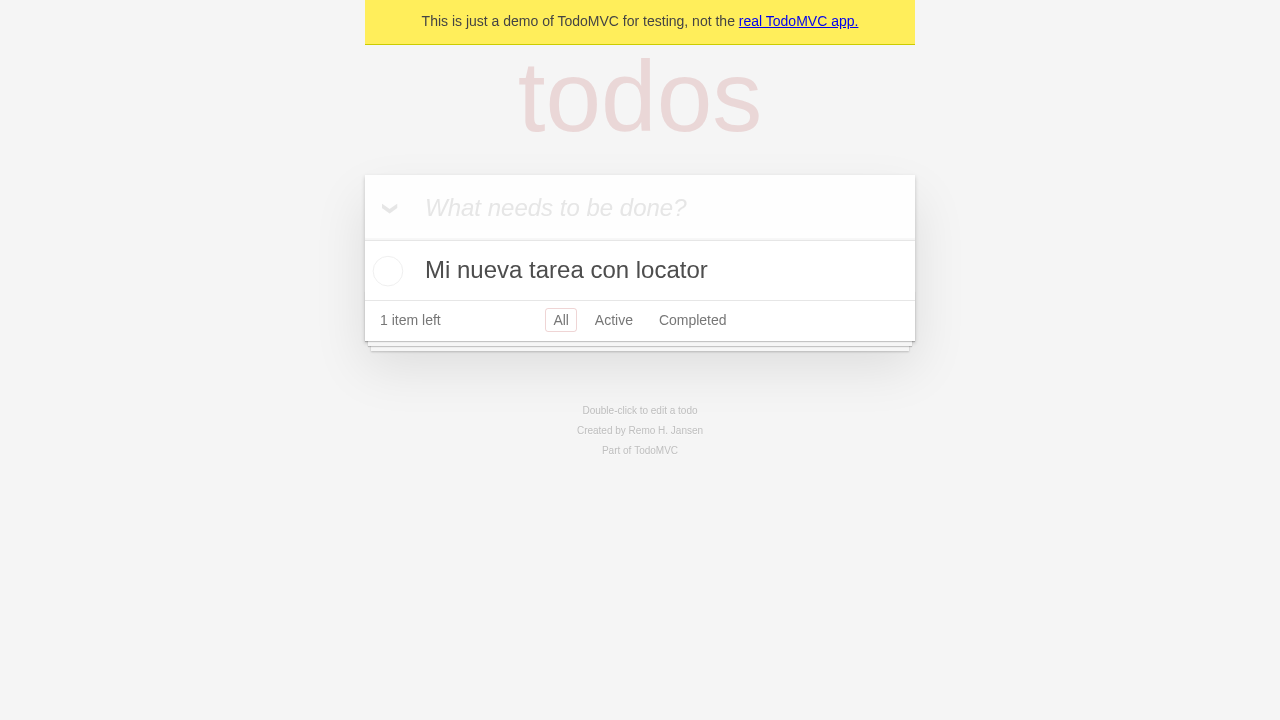

In [4]:
import asyncio
from playwright.async_api import async_playwright, expect

async def add_task_example():
    async with async_playwright() as pw:
        browser = await pw.chromium.launch(headless=True)
        page = await browser.new_page()

        # Navegar a la aplicación
        await page.goto('https://demo.playwright.dev/todomvc')
        await page.evaluate("localStorage.clear();") # Limpiar para un estado inicial limpio
        await page.reload()

        # 1. Localizar el campo de entrada usando get_by_placeholder
        input_nueva_tarea = page.get_by_placeholder('What needs to be done?')

        # 2. Escribir la nueva tarea en el campo de entrada
        await input_nueva_tarea.fill('Mi nueva tarea con locator')

        # 3. Presionar 'Enter' para agregar la tarea
        await input_nueva_tarea.press('Enter')

        # 4. Verificar que la tarea aparece en la lista
        await expect(page.get_by_text('Mi nueva tarea con locator')).to_be_visible()
        await expect(page.locator('.todo-list li')).to_have_count(1)

        print('✅ Tarea "Mi nueva tarea con locator" agregada y verificada.')

        # Opcional: tomar una captura de pantalla
        await page.screenshot(path='/tmp/tarea_agregada_locator.png')
        from IPython.display import Image, display
        display(Image('/tmp/tarea_agregada_locator.png', width=700))

        await browser.close()

await add_task_example()

---
## 🎬 Demo 1 — Navegar, Localizar y Hacer Assertions

Los tres pilares de cualquier test E2E:
1. **Navegar** a una URL
2. **Localizar** un elemento (con locators robustos)
3. **Verificar** el comportamiento esperado

📸 ✅ App cargada correctamente


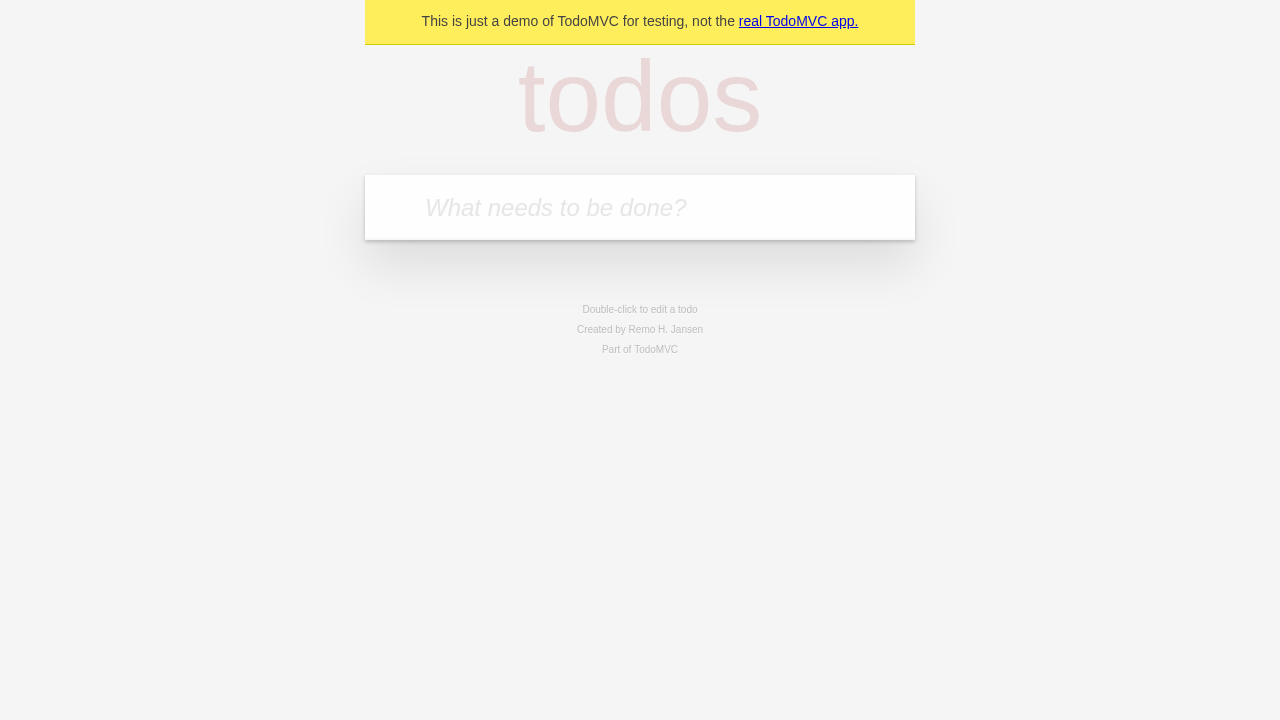

URL actual: https://demo.playwright.dev/todomvc/#/
Título:     React • TodoMVC


In [ ]:
# ── Demo 1: Navegar y verificar que la app carga ─────────────

import asyncio
from playwright.async_api import async_playwright

async def run_demo1():
    async with async_playwright() as pw:
        browser = await pw.chromium.launch(headless=True)
        page = await browser.new_page()

        # 1. NAVEGAR
        await page.goto(TODO_URL)

        # 2. LOCALIZAR — por rol semántico (recomendado)
        titulo = page.get_by_role('heading', name='todos')
        input_nueva = page.get_by_placeholder('What needs to be done?')

        # 3. VERIFICAR con expect() — tiene auto-retry hasta 5s
        await expect(titulo).to_be_visible()
        await expect(input_nueva).to_be_visible()
        await expect(input_nueva).to_be_enabled()

        # También podemos verificar el título de la página
        await expect(page).to_have_title(re.compile('TodoMVC', re.IGNORECASE))

        await screenshot(page, 'demo1_carga', '✅ App cargada correctamente')
        print(f'URL actual: {page.url}')
        print(f'Título:     {await page.title()}')

        await browser.close()

# To run the async function in Colab
await run_demo1()

### Tipos de locators — Orden de preferencia

```python
# ✅ MEJORES — semánticos y robustos
page.get_by_role('button', name='Guardar')     # Por rol ARIA
page.get_by_label('Correo electrónico')         # Por label de formulario
page.get_by_placeholder('¿Qué necesitas hacer?')
page.get_by_test_id('submit-btn')              # data-testid

# ⚠️ ACEPTABLES
page.get_by_text('Iniciar sesión')             # Texto visible
page.locator('#mi-id')                          # Por ID

# ❌ EVITAR — frágiles
page.locator('.btn-submit-v2-active')           # CSS específico
page.locator('/html/body/div[2]/button')        # XPath absoluto
```

---
## 🎬 Demo 2 — Interacción: Crear y Verificar Tareas

📸 ✅ 3 tareas creadas correctamente


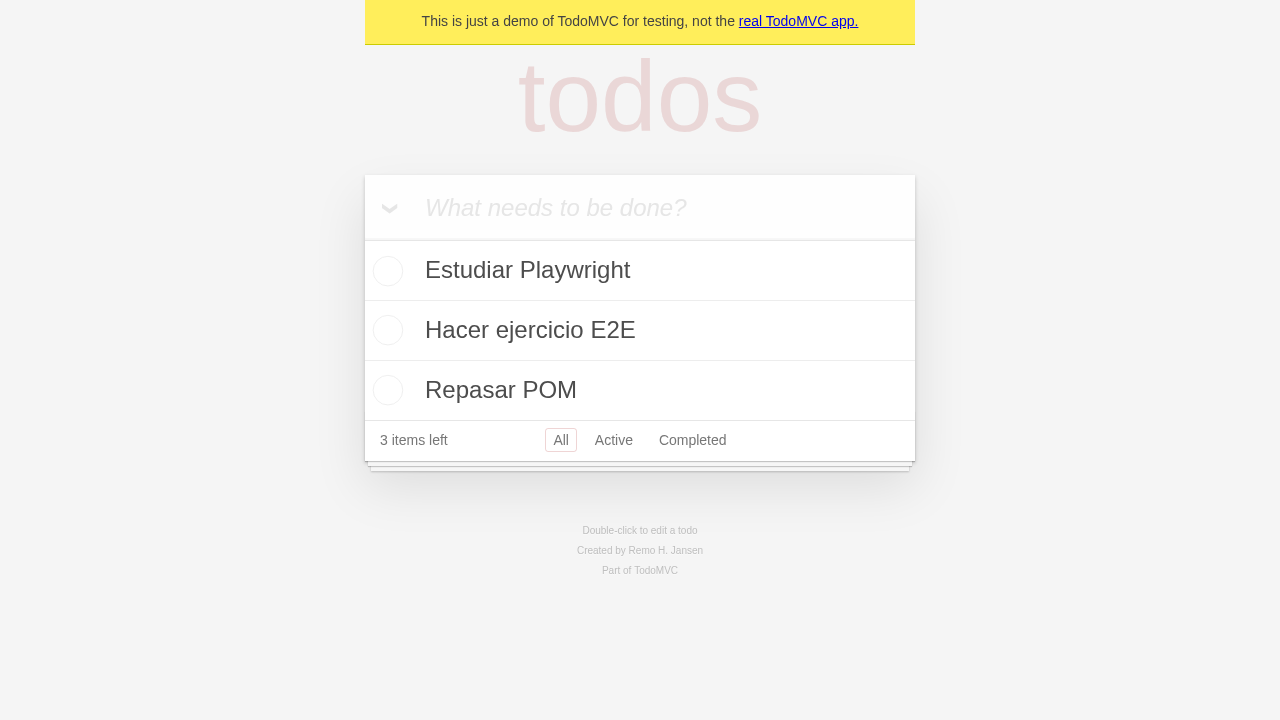

Tareas en pantalla: 3
📸 ✅ Primera tarea completada


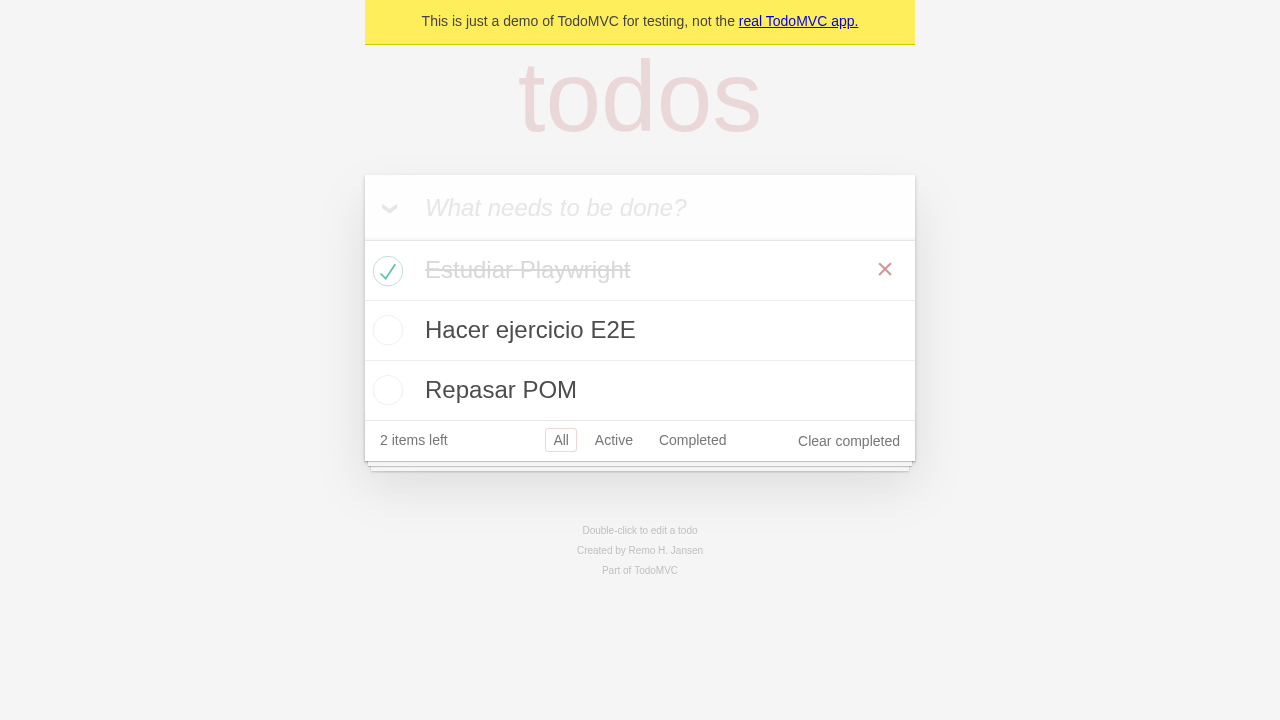

📸 ✅ Filtro "Active" — solo 2 tareas visibles


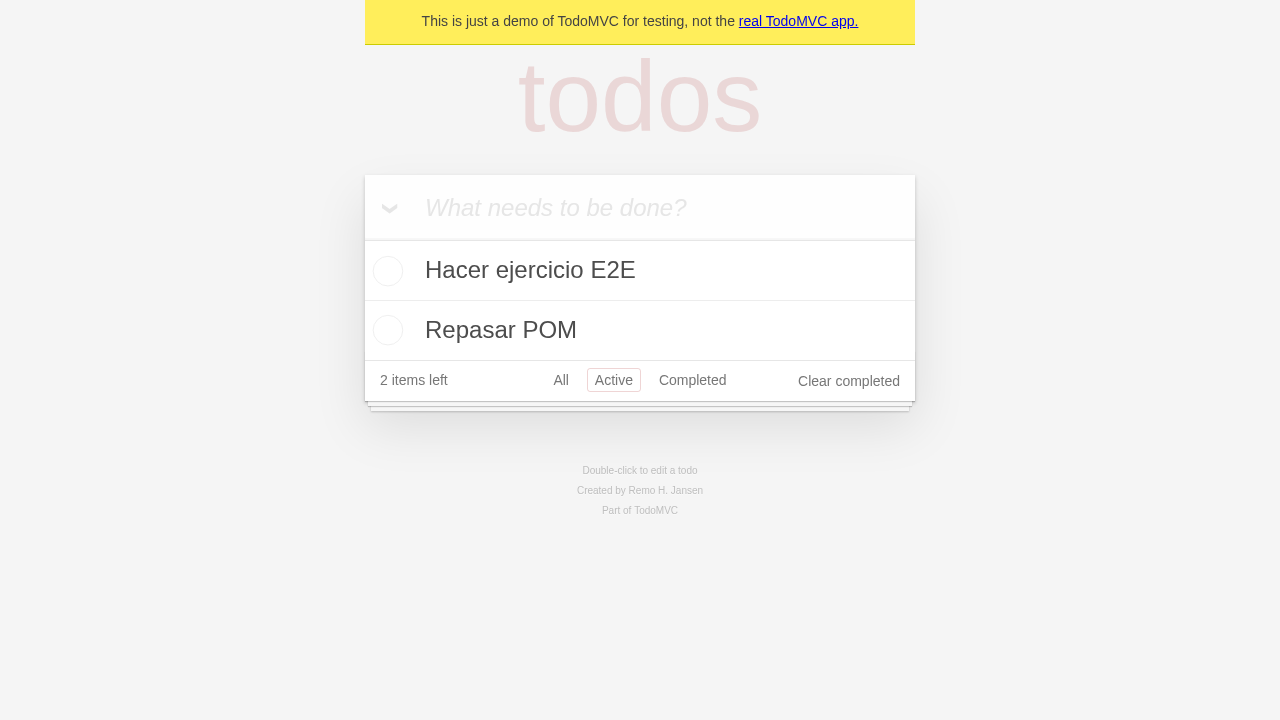


✅ Demo 2 completada — interacción verificada


In [ ]:
# ── Demo 2: Crear tareas e interactuar con la UI ─────────────

import asyncio
from playwright.async_api import async_playwright, expect

async def run_demo2():
    async with async_playwright() as pw:
        browser = await pw.chromium.launch(headless=True)
        page = await browser.new_page()

        # Asegurar un estado limpio: limpiar localStorage y recargar la página
        await page.goto(TODO_URL)
        await page.evaluate("localStorage.clear();")
        await page.reload()

        input_nueva = page.get_by_placeholder('What needs to be done?')

        # ── CREAR 3 TAREAS ────────────────────────────────────────
        tareas = ['Estudiar Playwright', 'Hacer ejercicio E2E', 'Repasar POM']

        for tarea in tareas:
            await input_nueva.fill(tarea)        # Escribe el texto
            await input_nueva.press('Enter')     # Confirma con Enter

        # ── VERIFICAR QUE LAS 3 TAREAS EXISTEN ───────────────────
        items = page.locator('.todo-list li') # Changed to a more specific locator
        await expect(items).to_have_count(3)

        # Verificar textos específicos
        for tarea in tareas:
            await expect(page.get_by_text(tarea)).to_be_visible()

        await screenshot(page, 'demo2_tareas', '✅ 3 tareas creadas correctamente')
        print(f'Tareas en pantalla: {await items.count()}')

        # ── COMPLETAR UNA TAREA ───────────────────────────────────
        # Marca la primera tarea como completada
        primera = page.locator('.todo-list li').first # Changed to a more specific locator
        await primera.get_by_role('checkbox').check()

        # Verificar que tiene clase 'completed'
        await expect(primera).to_have_class(re.compile('completed'))

        await screenshot(page, 'demo2_completada', '✅ Primera tarea completada')

        # ── FILTRAR: solo activas ─────────────────────────────────
        await page.get_by_role('link', name='Active').click()

        # Solo deben verse las 2 tareas no completadas
        await expect(page.locator('.todo-list li')).to_have_count(2) # Changed to a more specific locator

        await screenshot(page, 'demo2_filtro', '✅ Filtro "Active" — solo 2 tareas visibles')

        await browser.close()
        print('\n✅ Demo 2 completada — interacción verificada')

await run_demo2()

---
## 🏗️ Demo 3 — Page Object Model (POM)

El patrón POM encapsula los **selectores y acciones** de cada página en una clase reutilizable.  
Los tests solo llaman métodos de alto nivel — sin conocer los detalles internos de la UI.

In [ ]:
class TodoPage:
    """
    Page Object para la app TodoMVC.
    Encapsula todos los selectores y acciones.
    Los tests nunca conocen los detalles internos de la UI.
    """

    URL = 'https://demo.playwright.dev/todomvc'

    def __init__(self, page: Page):
        self.page = page
        # ── Locators centralizados ──────────────────────────
        self.input_nueva    = page.get_by_placeholder('What needs to be done?')
        self.items          = page.locator('.todo-list li') # Cambiado a un selector más específico
        self.toggle_all     = page.get_by_label('Mark all as complete')
        self.contador       = page.locator('.todo-count strong')
        self.filtro_all     = page.get_by_role('link', name='All')
        self.filtro_active  = page.get_by_role('link', name='Active')
        self.filtro_done    = page.get_by_role('link', name='Completed')
        self.clear_done_btn = page.get_by_role('button', name='Clear completed')
        self.contador_texto = page.locator('.todo-count') # Added this locator

    async def navigate(self):
        await self.page.goto(self.URL)

    async def agregar_tarea(self, texto: str):
        """Crea una nueva tarea con el texto dado."""
        await self.input_nueva.fill(texto)
        await self.input_nueva.press('Enter')

    async def agregar_tareas(self, textos: list):
        """Crea múltiples tareas de una vez."""
        for texto in textos:
            await self.agregar_tarea(texto)

    async def completar_tarea(self, texto: str):
        """Marca como completada la tarea con el texto dado."""
        item = self.items.filter(has_text=texto)
        await item.get_by_role('checkbox').check()

    async def eliminar_tarea(self, texto: str):
        """Elimina la tarea con el texto dado (hover + clic en X)."""
        item = self.items.filter(has_text=texto)
        await item.hover()
        await item.get_by_role('button', name='Delete').click()

    async def get_conteo_pendientes(self) -> int:
        """Retorna el número de tareas pendientes según el contador."""
        return int(await self.contador.inner_text())

    async def get_conteo_items(self) -> int:
        """Retorna el número de items visibles en la lista."""
        return await self.items.count()

    async def filtrar_activas(self):
        await self.filtro_active.click()

    async def filtrar_completadas(self):
        await self.filtro_done.click()

    async def filtrar_todas(self):
        await self.filtro_all.click()

    async def limpiar_completadas(self):
        await self.clear_done_btn.click()


print('✅ Clase TodoPage definida.')
print('   Los tests ahora llaman métodos como:')
print('   todo.agregar_tarea("Estudiar")  — sin conocer los selectores internos')

✅ Clase TodoPage definida.
   Los tests ahora llaman métodos como:
   todo.agregar_tarea("Estudiar")  — sin conocer los selectores internos


📸 App vacía al inicio


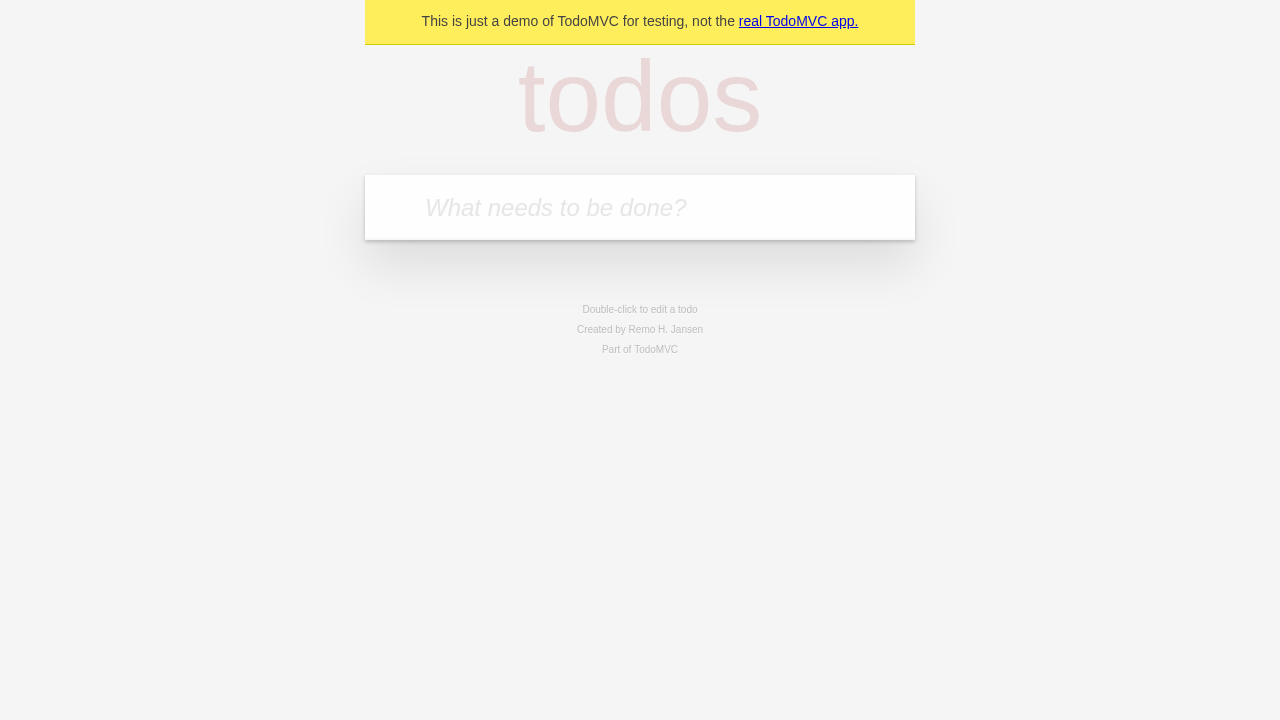

📸 4 tareas creadas


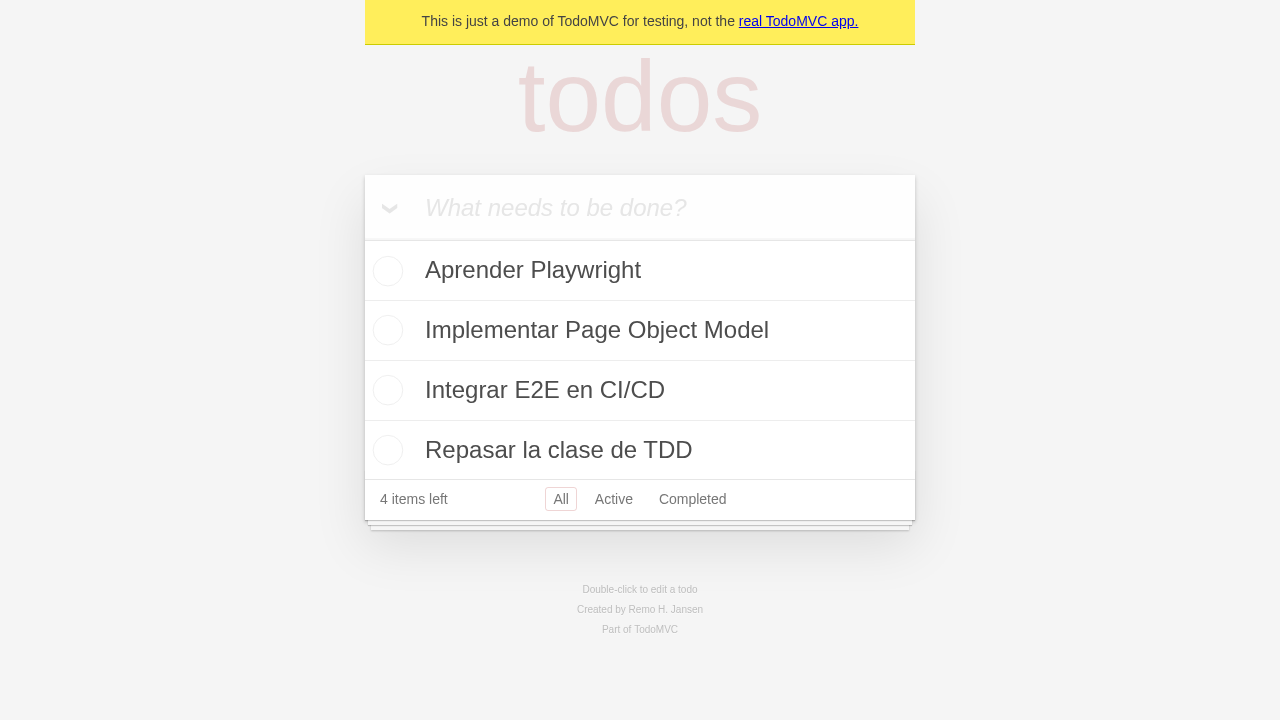

Pendientes: 4
📸 2 tareas completadas


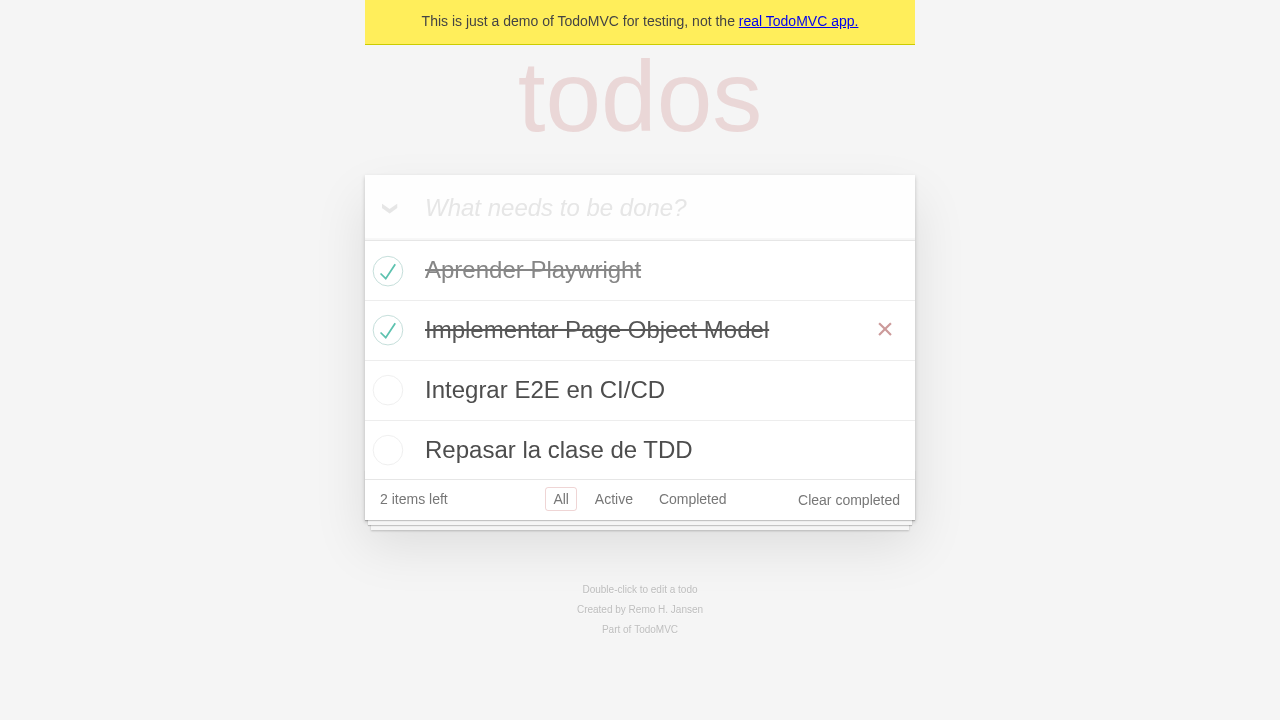

Pendientes después de completar 2: 2
📸 Filtro: solo activas (2)


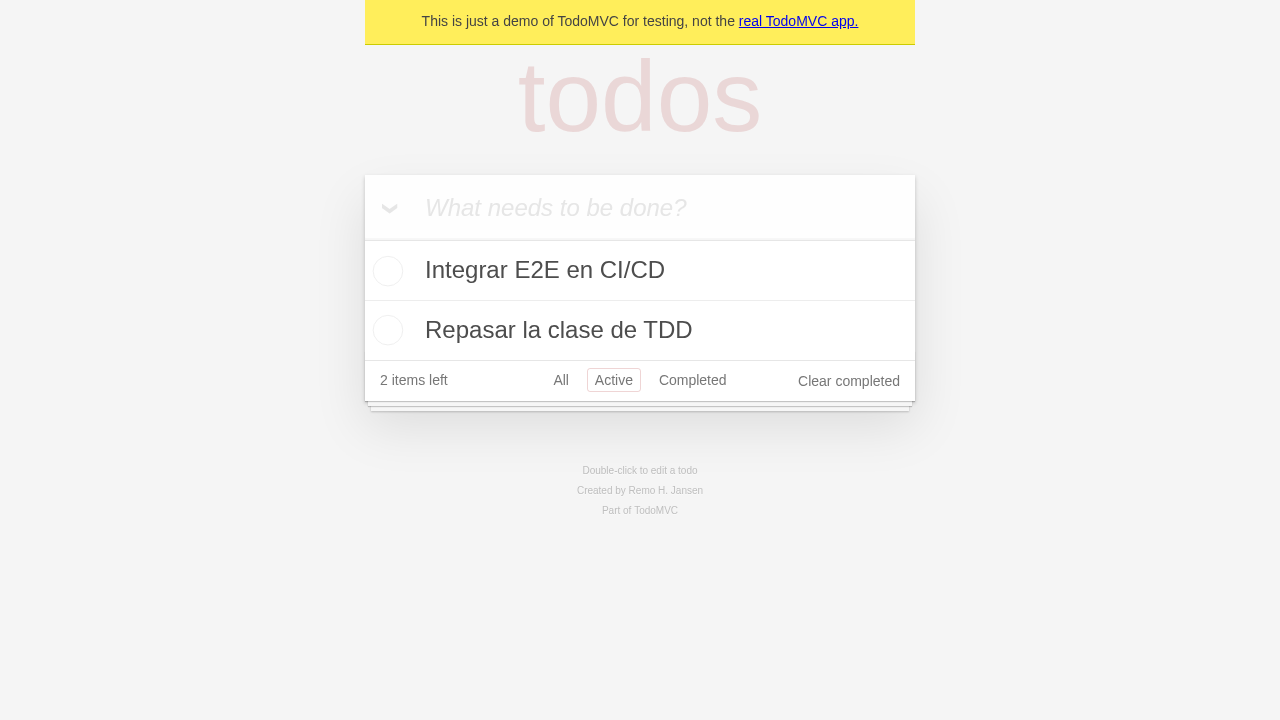

📸 Filtro: solo completadas (2)


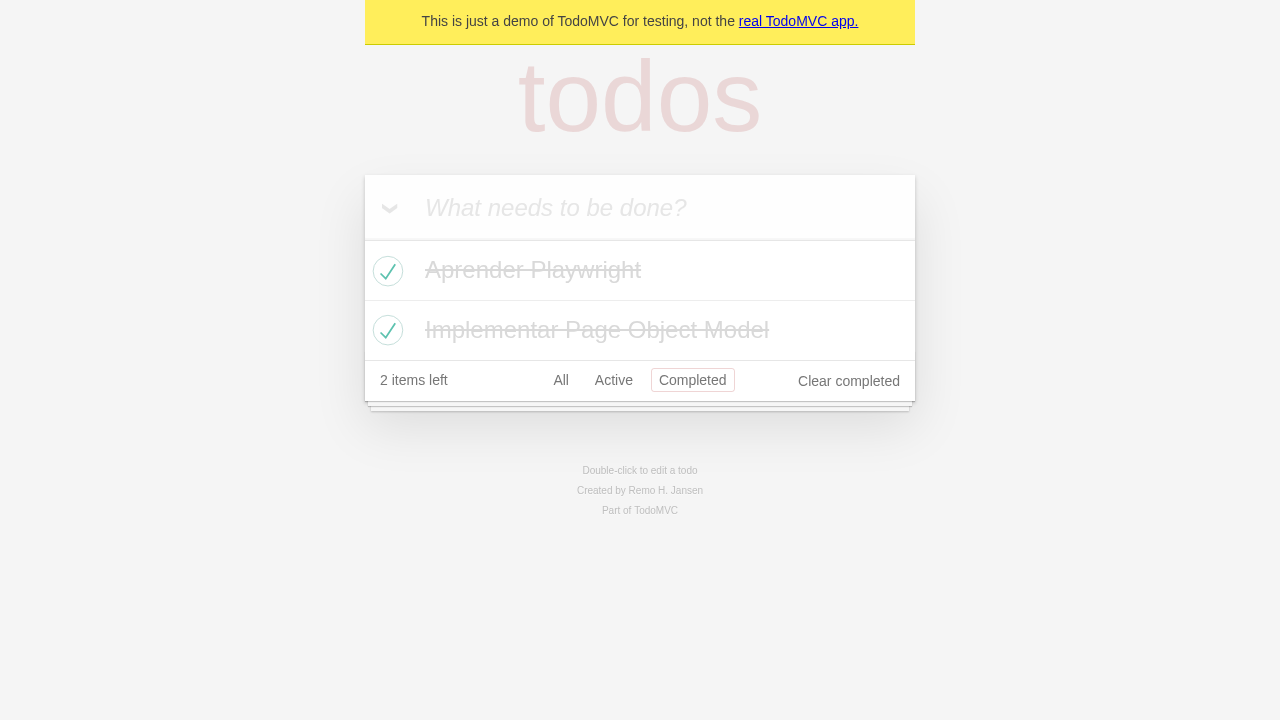

📸 Completadas eliminadas — quedan 2


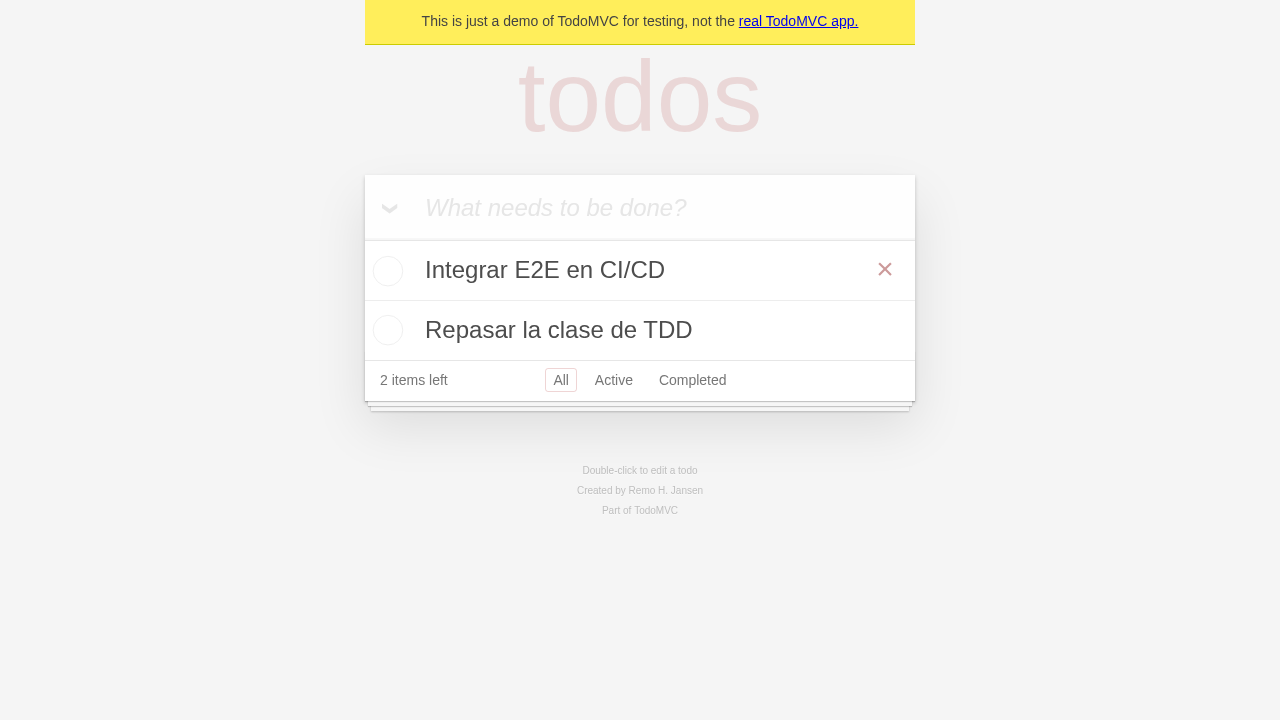

Items después de limpiar: 2

✅ Flujo completo con POM — todos los assertions pasaron


In [ ]:
# ── Demo 3: Flujo completo usando el POM ─────────────────────
# Observa cómo el test es legible y no contiene selectores

import asyncio
from playwright.async_api import async_playwright, expect

async def run_demo3():
    async with async_playwright() as pw:
        browser = await pw.chromium.launch(headless=True)
        page = await browser.new_page()
        todo = TodoPage(page)

        # Asegurar un estado limpio para esta demo
        await page.goto(TODO_URL) # Necesario para que localStorage.clear() funcione en la página correcta
        await page.evaluate("localStorage.clear();")
        await page.reload()

        # ── ARRANQUE ──────────────────────────────────────────────
        await todo.navigate()
        await screenshot(page, 'pom_inicio', 'App vacía al inicio')

        # ── CREAR TAREAS ──────────────────────────────────────────
        await todo.agregar_tareas([
            'Aprender Playwright',
            'Implementar Page Object Model',
            'Integrar E2E en CI/CD',
            'Repasar la clase de TDD',
        ])

        await expect(todo.items).to_have_count(4)
        await expect(todo.contador_texto).to_have_text('4 items left') # Usar el nuevo locator
        await screenshot(page, 'pom_4tareas', '4 tareas creadas')
        print(f'Pendientes: {await todo.get_conteo_pendientes()}')

        # ── COMPLETAR ALGUNAS ─────────────────────────────────────
        await todo.completar_tarea('Aprender Playwright')
        await todo.completar_tarea('Implementar Page Object Model')

        await expect(todo.contador_texto).to_have_text('2 items left') # Usar el nuevo locator
        await screenshot(page, 'pom_completadas', '2 tareas completadas')
        print(f'Pendientes después de completar 2: {await todo.get_conteo_pendientes()}')

        # ── FILTROS ───────────────────────────────────────────────
        await todo.filtrar_activas()
        await expect(todo.items).to_have_count(2)
        await screenshot(page, 'pom_activas', 'Filtro: solo activas (2)')

        await todo.filtrar_completadas()
        await expect(todo.items).to_have_count(2)
        await screenshot(page, 'pom_completadas_filtro', 'Filtro: solo completadas (2)')

        # ── LIMPIAR COMPLETADAS ───────────────────────────────────
        await todo.limpiar_completadas()
        await todo.filtrar_todas()
        await expect(todo.items).to_have_count(2)
        await screenshot(page, 'pom_limpio', 'Completadas eliminadas — quedan 2')
        print(f'Items después de limpiar: {await todo.get_conteo_items()}')

        await browser.close()
        print('\n✅ Flujo completo con POM — todos los assertions pasaron')

await run_demo3()

---

## 🎯 Ejercicio de Cierre — 15 Minutos

### Contexto

Ya tienes la clase `TodoPage` lista. Tu trabajo es escribir **5 funciones de test** que cubran los escenarios indicados. Cada función debe usar `TodoPage` — sin selectores directos en los tests.

### Reglas

- ✅ Usa **solo métodos de `TodoPage`** en los tests (no `page.locator()` directamente)
- ✅ Usa **`expect()`** para las verificaciones (no solo `assert`)
- ✅ Cada test debe ser **independiente** (navega al inicio en cada uno)
- ❌ No uses `time.sleep()` — Playwright maneja los tiempos automáticamente

### Tests a implementar

| # | Nombre del test | Descripción |
|---|-----------------|-------------|
| 1 | `test_app_inicia_vacia` | Al abrir la app, la lista de tareas debe estar vacía |
| 2 | `test_crear_tarea_aparece_en_lista` | Al crear una tarea, debe aparecer visible en la lista |
| 3 | `test_completar_tarea_reduce_contador` | Al completar 1 de 3, el contador baja a 2 |
| 4 | `test_filtro_active_oculta_completadas` | El filtro Active solo muestra las no completadas |
| 5 | `test_limpiar_completadas_las_elimina` | Clear completed elimina solo las completadas |



  RESULTADOS DE LOS TESTS
  ❌ FAIL  test_app_inicia_vacia
         └─ name 'TodoPage' is not defined
  ❌ FAIL  test_crear_tarea_aparece_en_lista
         └─ name 'TodoPage' is not defined
  ❌ FAIL  test_completar_tarea_reduce_contador
         └─ name 'TodoPage' is not defined
  ❌ FAIL  test_filtro_active_oculta_completadas
         └─ name 'TodoPage' is not defined
  ❌ FAIL  test_filtro_completadas_muestra_solo_completadas
         └─ name 'TodoPage' is not defined
  ❌ FAIL  test_limpiar_completadas_las_elimina
         └─ name 'TodoPage' is not defined
  0/6 tests pasaron

└─ 6 test(s) pendientes. ¡Sigue adelante!

└─ Estado final de cada test:

  → test_app_inicia_vacia


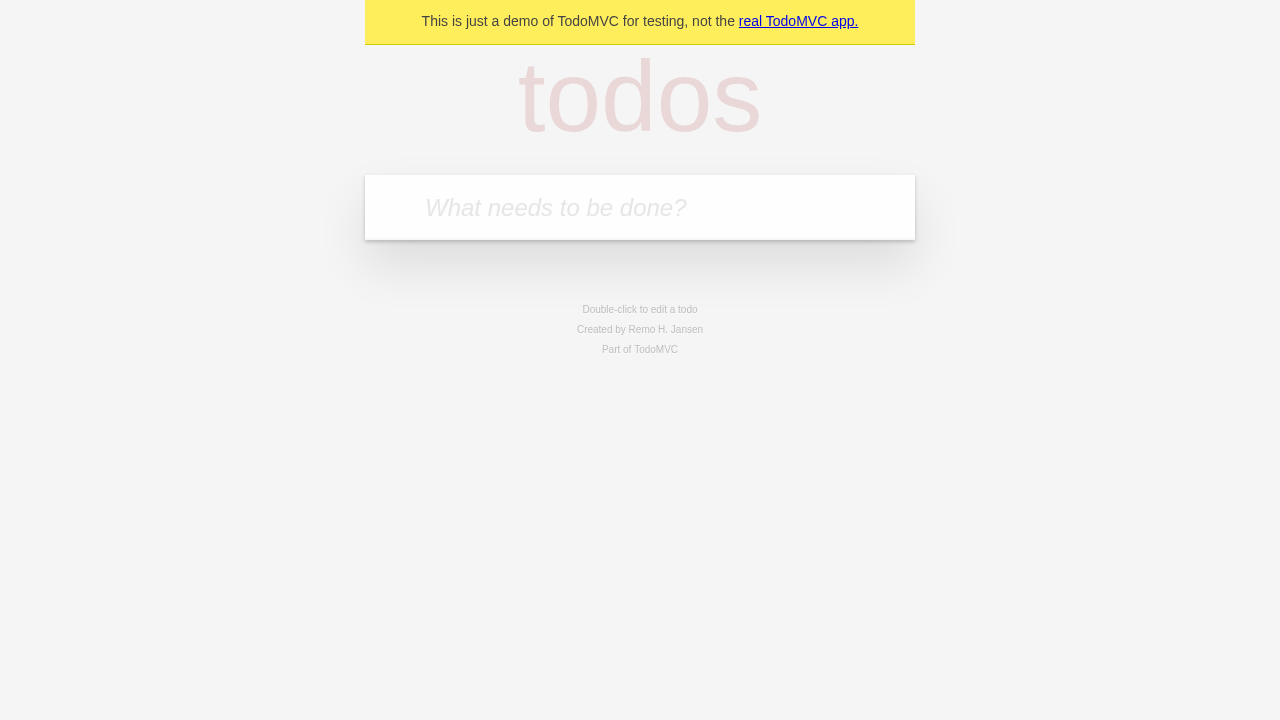


  → test_crear_tarea_aparece_en_lista


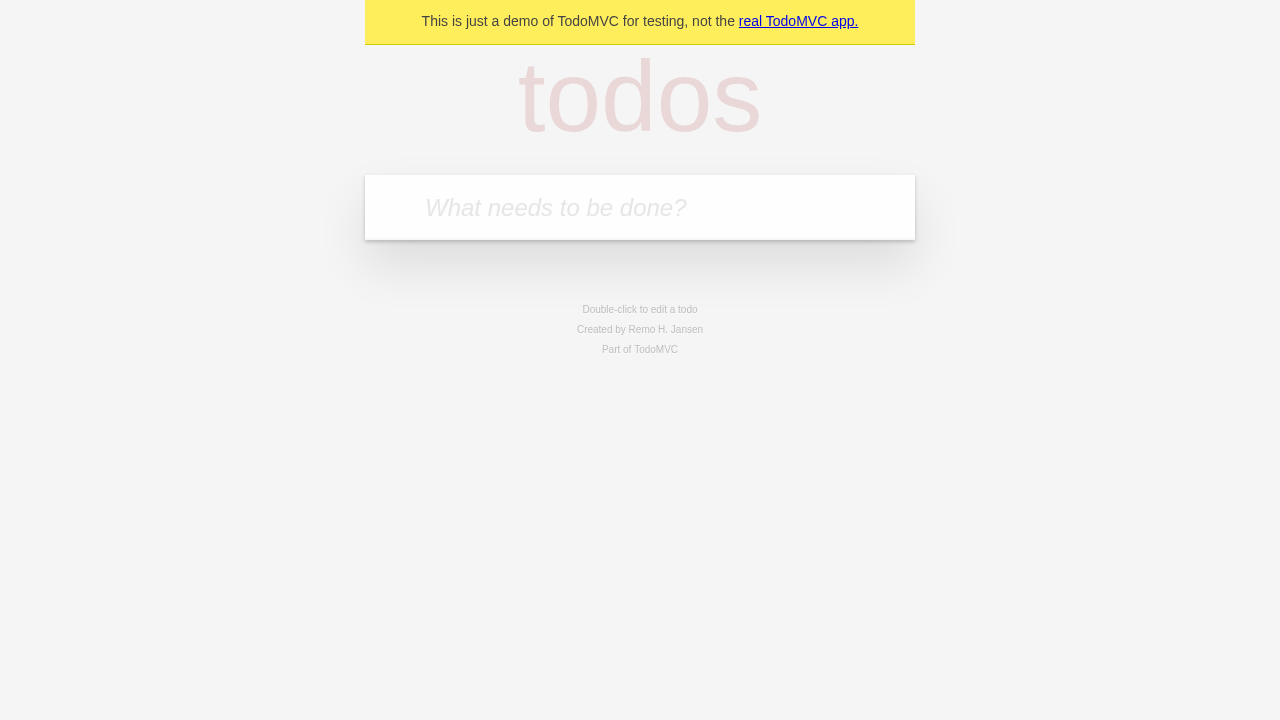


  → test_completar_tarea_reduce_contador


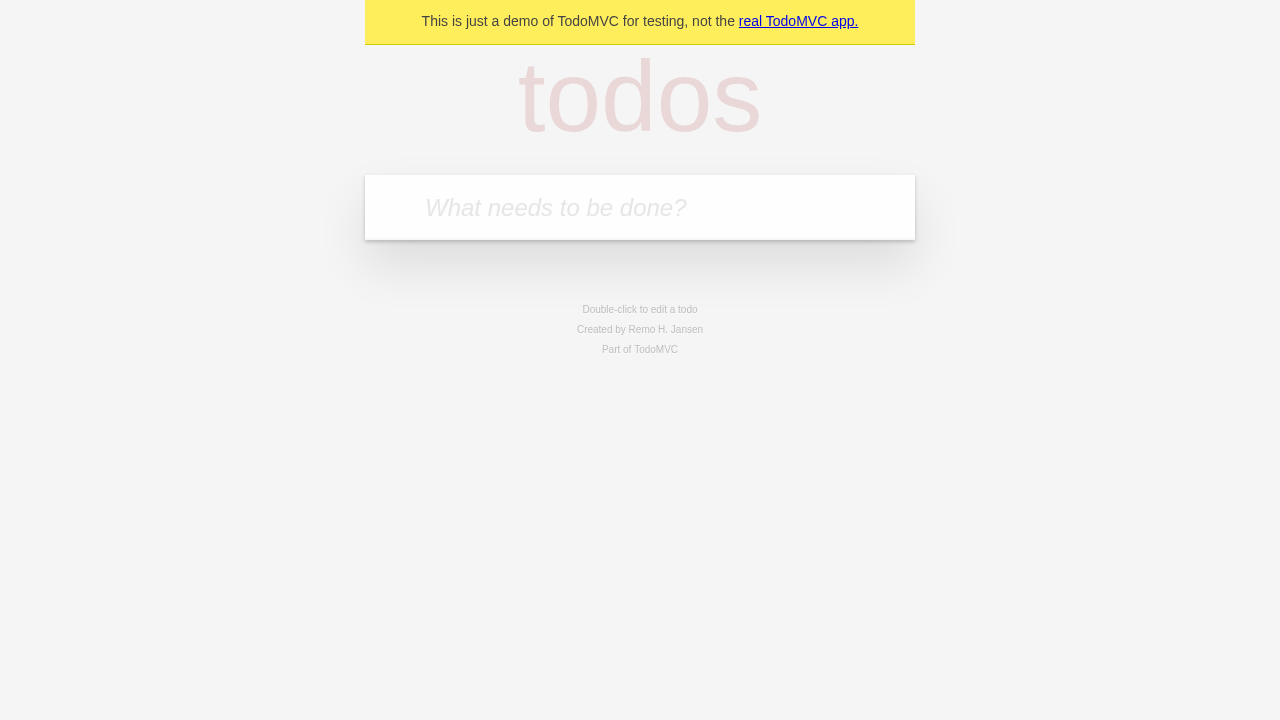


  → test_filtro_active_oculta_completadas


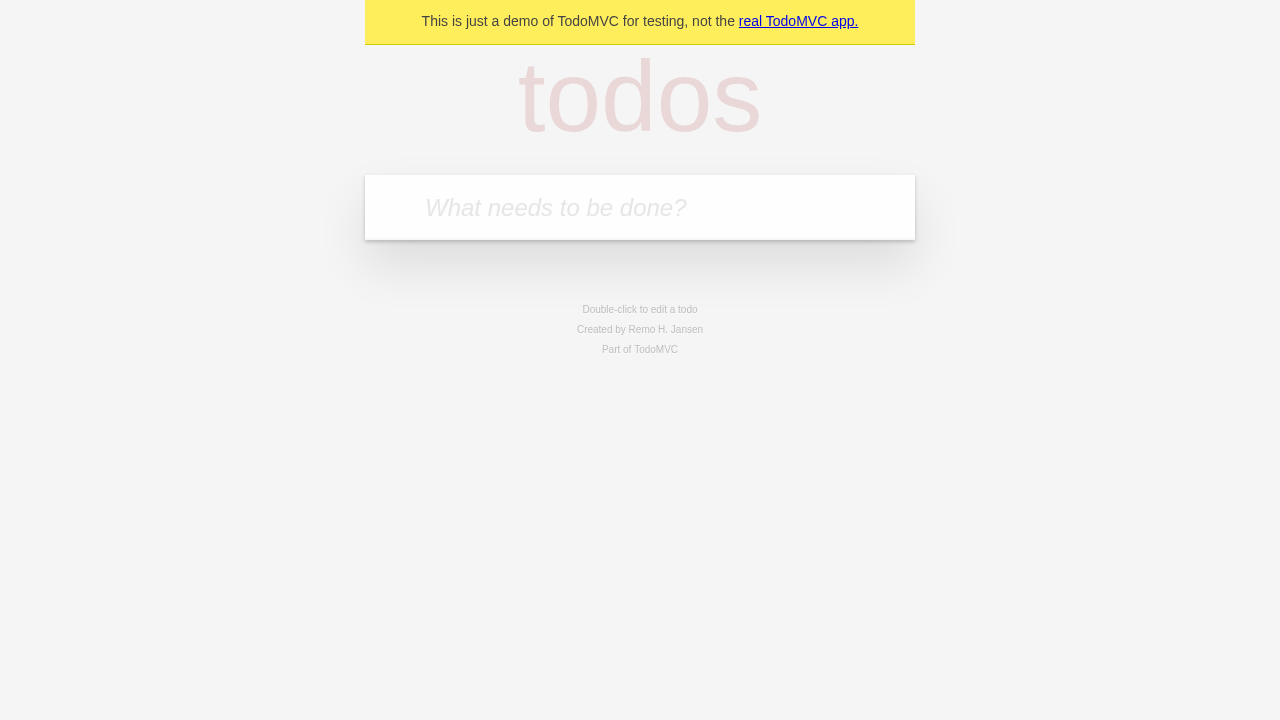


  → test_filtro_completadas_muestra_solo_completadas


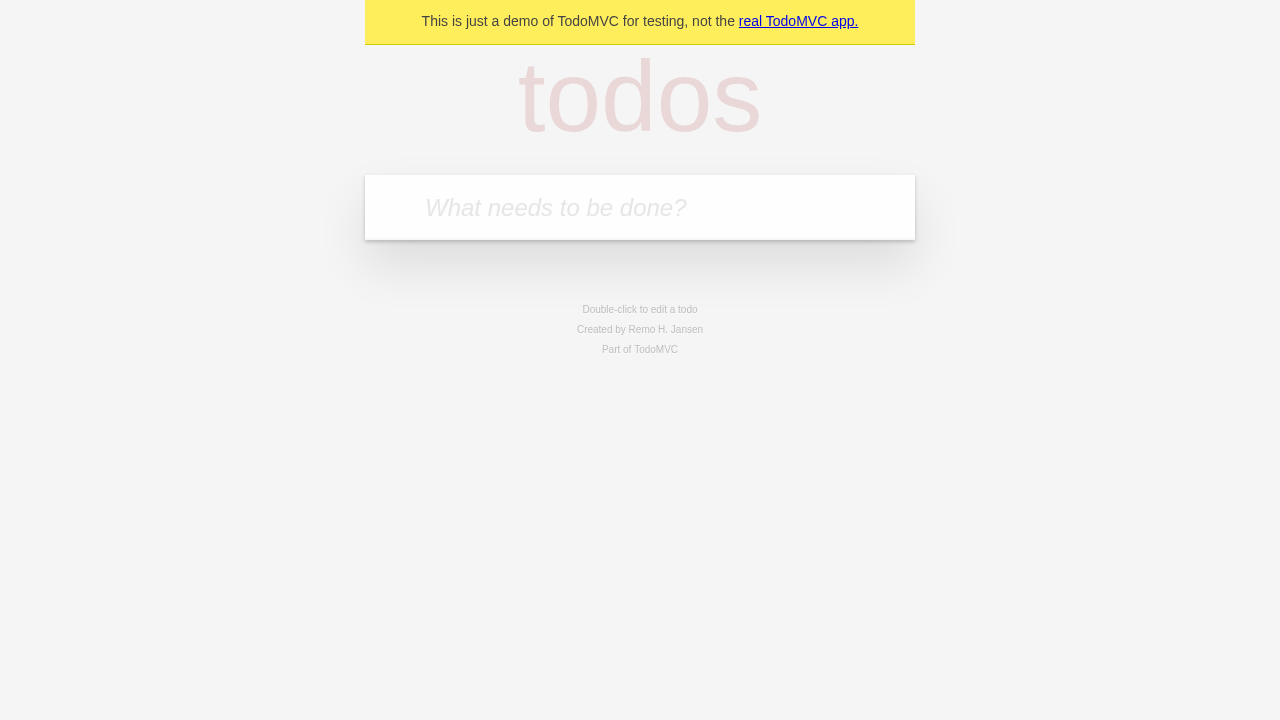


  → test_limpiar_completadas_las_elimina


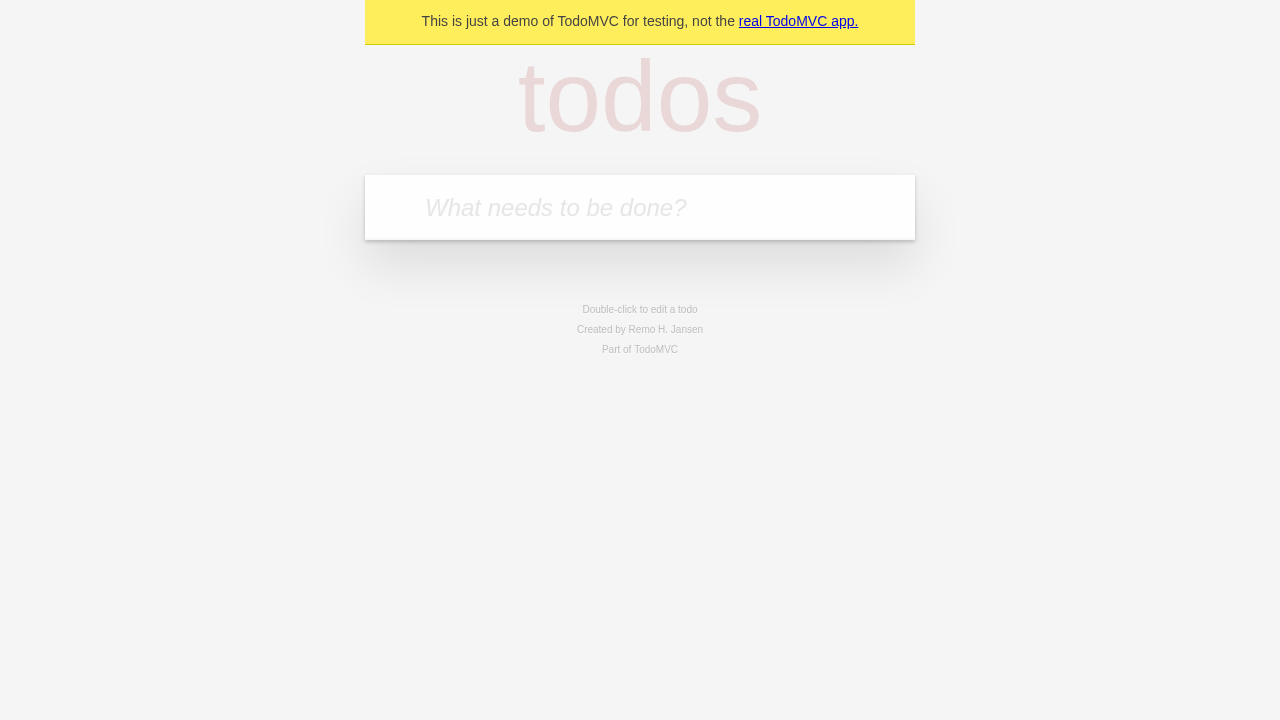

In [7]:
import asyncio
from playwright.async_api import async_playwright, Page, expect # Aseguramos que expect también es de la API asíncrona

# ════════════════════════════════════
#  EJERCICIO ─ Completa las funciones de test
#  Ejecuta esta celda cuando termines para ver los resultados
# ════════════════════════════════════

async def test_app_inicia_vacia(page: Page):
    """
    DADO:    abro la app por primera vez
    CUANDO:  no he creado ninguna tarea
    ENTONCES: la lista de tareas debe estar vacía (count=0)
    """
    todo = TodoPage(page)
    await todo.navigate()

    # TODO: verificar que no hay items
    # Pista: expect(todo.items).to_have_count(?)
    await expect(todo.items).to_have_count(0)


async def test_crear_tarea_aparece_en_lista(page: Page):
    """
    DADO:    la app está vacía
    CUANDO:  creo la tarea 'Estudiar Playwright'
    ENTONCES: esa tarea aparece visible en la lista
    """
    todo = TodoPage(page)
    await todo.navigate()

    # TODO: crear una tarea
    await todo.agregar_tarea('Estudiar Playwright')
    await expect(todo.items).to_have_count(1)
    await expect(page.get_by_text('Estudiar Playwright')).to_be_visible()


async def test_completar_tarea_reduce_contador(page: Page):
    """
    DADO:    tengo 3 tareas pendientes
    CUANDO:  completo la primera
    ENTONCES: el contador de pendientes baja a 2
    """
    todo = TodoPage(page)
    await todo.navigate()
    await todo.agregar_tareas(['Tarea A', 'Tarea B', 'Tarea C'])

    # TODO: completar una tarea
    await todo.completar_tarea('Tarea A')
    await expect(todo.contador).to_have_text('2')



async def test_filtro_active_oculta_completadas(page: Page):
    """
    DADO:    tengo 3 tareas y completo 1
    CUANDO:  activo el filtro 'Active'
    ENTONCES: solo se ven 2 tareas (las no completadas)
    """
    todo = TodoPage(page)
    await todo.navigate()
    await todo.agregar_tareas(['Primera', 'Segunda', 'Tercera'])
    await todo.completar_tarea('Primera')

    # TODO: completar una, filtrar activas, verificar count=2
    await todo.filtrar_activas()
    await expect(todo.items).to_have_count(2)
    await expect(page.get_by_text('Primera')).not_to_be_visible()

async def test_filtro_completadas_muestra_solo_completadas(page: Page):
    """
    DADO:    tengo 3 tareas y 2 están completadas
    CUANDO:  activo el filtro 'Completed'
    ENTONCES: solo se ven 2 tareas (las completadas)
    """
    todo = TodoPage(page)
    await todo.navigate()
    await todo.agregar_tareas(['Activa 1', 'Completada 1', 'Activa 2', 'Completada 2'])
    await todo.completar_tarea('Completada 1')
    await todo.completar_tarea('Completada 2')

   # TODO: filtrar completadas, verifica count=2
    await todo.filtrar_completadas()
    await expect(todo.items).to_have_count(2)
    await expect(page.get_by_text('Completada 1')).to_be_visible()
    await expect(page.get_by_text('Completada 2')).to_be_visible()
    await expect(page.get_by_text('Activa 1')).not_to_be_visible()
    await expect(page.get_by_text('Activa 2')).not_to_be_visible()

async def test_limpiar_completadas_las_elimina(page: Page):
    """
    DADO:    tengo 3 tareas y 2 están completadas
    CUANDO:  hago clic en 'Clear completed'
    ENTONCES: quedan exactamente 1 tarea (la no completada)
    """
    todo = TodoPage(page)
    await todo.navigate()
    await todo.agregar_tareas(['Keep me', 'Delete me 1', 'Delete me 2'])

    # TODO: completar las dos ultimas, limpiar, verificar count=1
    await todo.completar_tarea('Delete me 1')
    await todo.completar_tarea('Delete me 2')
    await todo.limpiar_completadas()
    await todo.filtrar_todas() # Ensure all tasks are visible to verify the count
    await expect(todo.items).to_have_count(1)
    await expect(page.get_by_text('Keep me')).to_be_visible()



# Define todos_los_tests BEFORE run_all_tests is defined
todos_los_tests = [
    test_app_inicia_vacia,
    test_crear_tarea_aparece_en_lista,
    test_completar_tarea_reduce_contador,
    test_filtro_active_oculta_completadas,
    test_filtro_completadas_muestra_solo_completadas,
    test_limpiar_completadas_las_elimina,
]

# Initialize these lists outside the function to collect results
resultados = []
screenshots_finales = []

async def run_all_tests():
    global resultados, screenshots_finales
    resultados = [] # Clear for re-runs
    screenshots_finales = [] # Clear for re-runs

    async with async_playwright() as pw:
        browser = await pw.chromium.launch(headless=True)

        for fn in todos_los_tests:
            page = await browser.new_page()
            nombre = fn.__name__
            try:
                # Clear localStorage and reload for a clean state before each test
                await page.goto(TODO_URL)
                await page.evaluate("localStorage.clear();")
                await page.reload()

                await fn(page) # Call the async test function with await
                path = f'/tmp/exec_{nombre}.png'
                await page.screenshot(path=path)
                screenshots_finales.append((path, nombre))
                resultados.append((nombre, '✅ PASS', None))
            except Exception as e:
                path = f'/tmp/fail_{nombre}.png'
                await page.screenshot(path=path)
                screenshots_finales.append((path, nombre))
                resultados.append((nombre, '❌ FAIL', str(e)[:120]))
            finally:
                await page.close()

        await browser.close()

    # Reporte
    print('\n' + '='*60)
    print('  RESULTADOS DE LOS TESTS')
    print('='*60)
    passed = sum(1 for _,s,_ in resultados if 'PASS' in s)
    for nombre, status, error in resultados:
        print(f'  {status}  {nombre}')
        if error:
            print(f'         \u2514\u2500 {error}')
    print('='*60)
    print(f'  {passed}/{len(resultados)} tests pasaron')
    print('='*60)

    if passed == len(resultados):
        print('\n\u2514\u2500 ¡Todos los tests pasan! Excelente trabajo.')
    else:
        print(f'\n\u2514\u2500 {len(resultados)-passed} test(s) pendientes. ¡Sigue adelante!')

# To run the async function in Colab
await run_all_tests()

# Display screenshots of each test
print('\n\u2514\u2500 Estado final de cada test:')
for path, nombre in screenshots_finales:
    print(f'\n  → {nombre}')
    display(Image(path, width=500))

In [6]:
!pip install playwright

---
## ✅ Solución Completa

> **No mirar hasta haber intentado el ejercicio.** 🙈


  SOLUCIÓN — RESULTADOS FINALES
  ✅ PASS  test_app_inicia_vacia
  ✅ PASS  test_crear_tarea_aparece_en_lista
  ✅ PASS  test_completar_tarea_reduce_contador
  ✅ PASS  test_filtro_active_oculta_completadas
  ✅ PASS  test_filtro_completadas_muestra_solo_completadas
  ✅ PASS  test_limpiar_completadas_las_elimina
  6/6 tests pasaron

📸 Estado final de cada test:

  → test_app_inicia_vacia


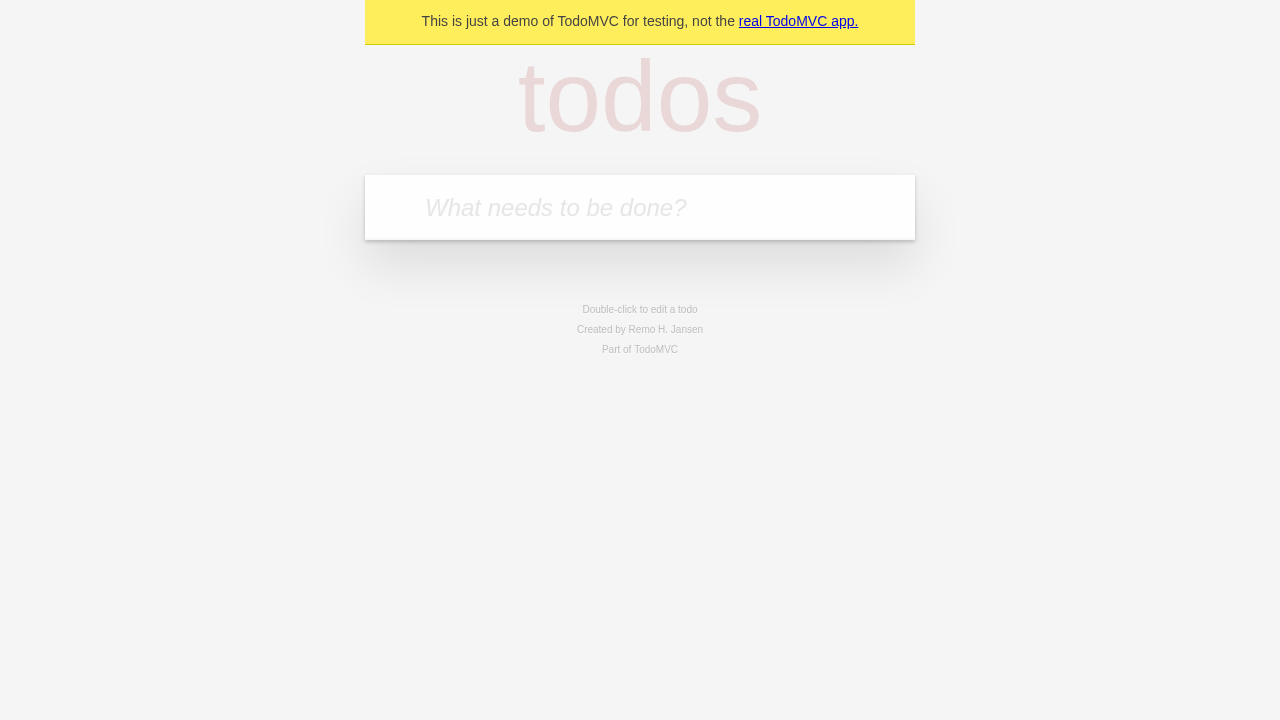


  → test_crear_tarea_aparece_en_lista


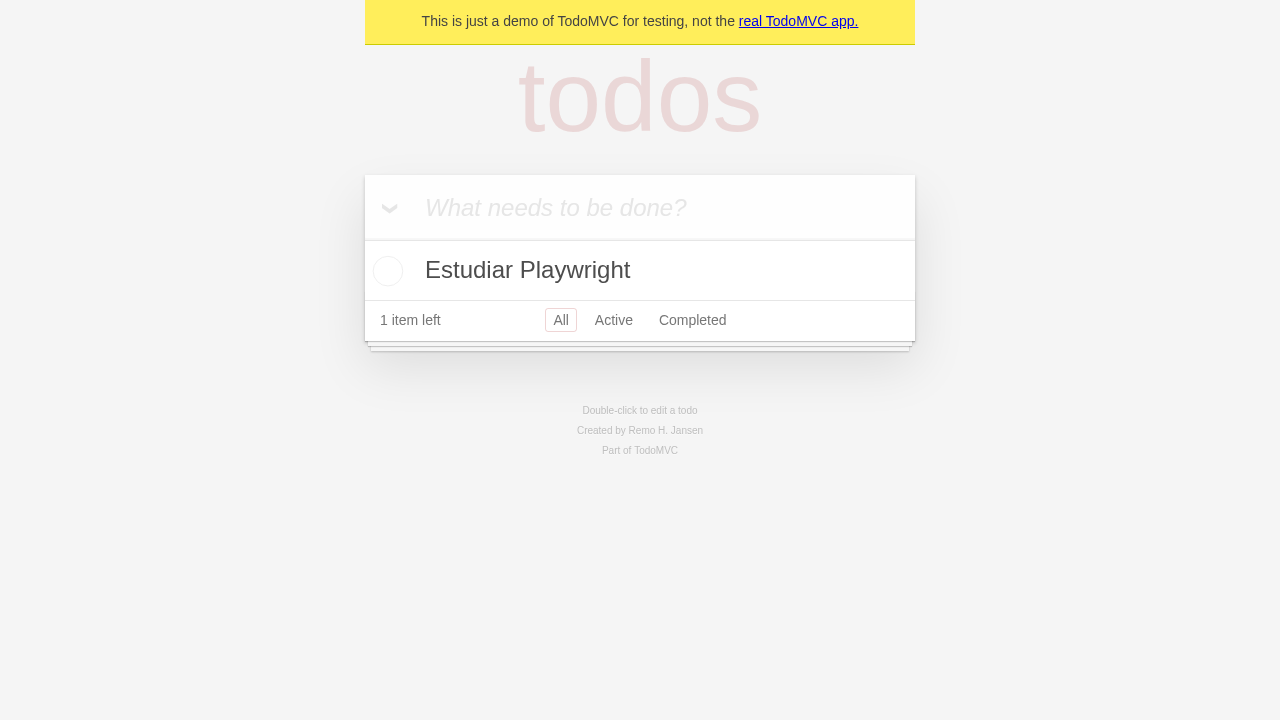


  → test_completar_tarea_reduce_contador


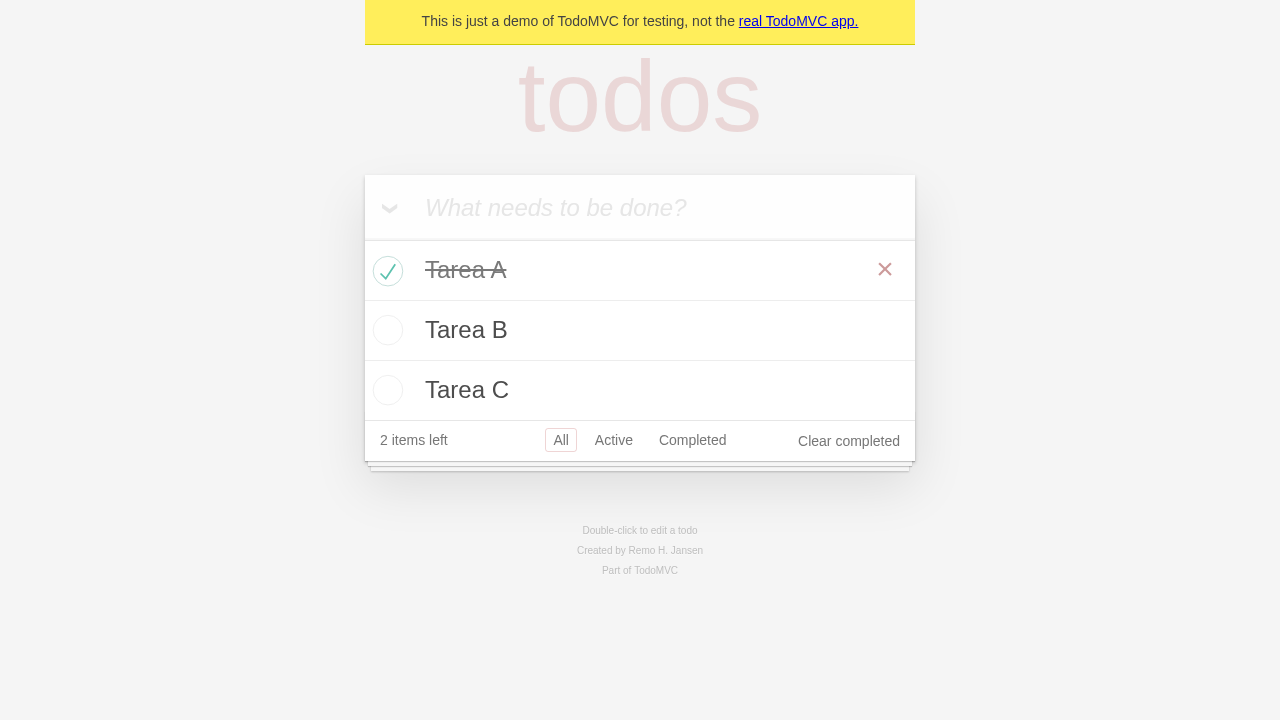


  → test_filtro_active_oculta_completadas


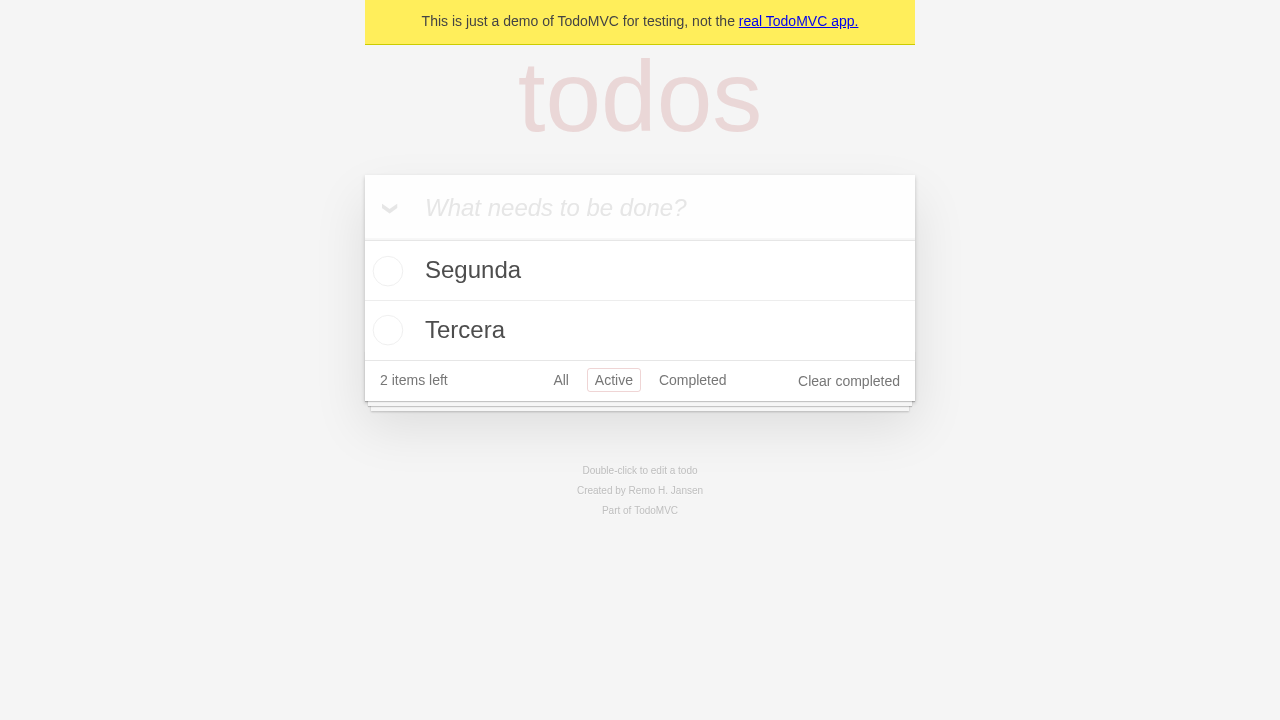


  → test_filtro_completadas_muestra_solo_completadas


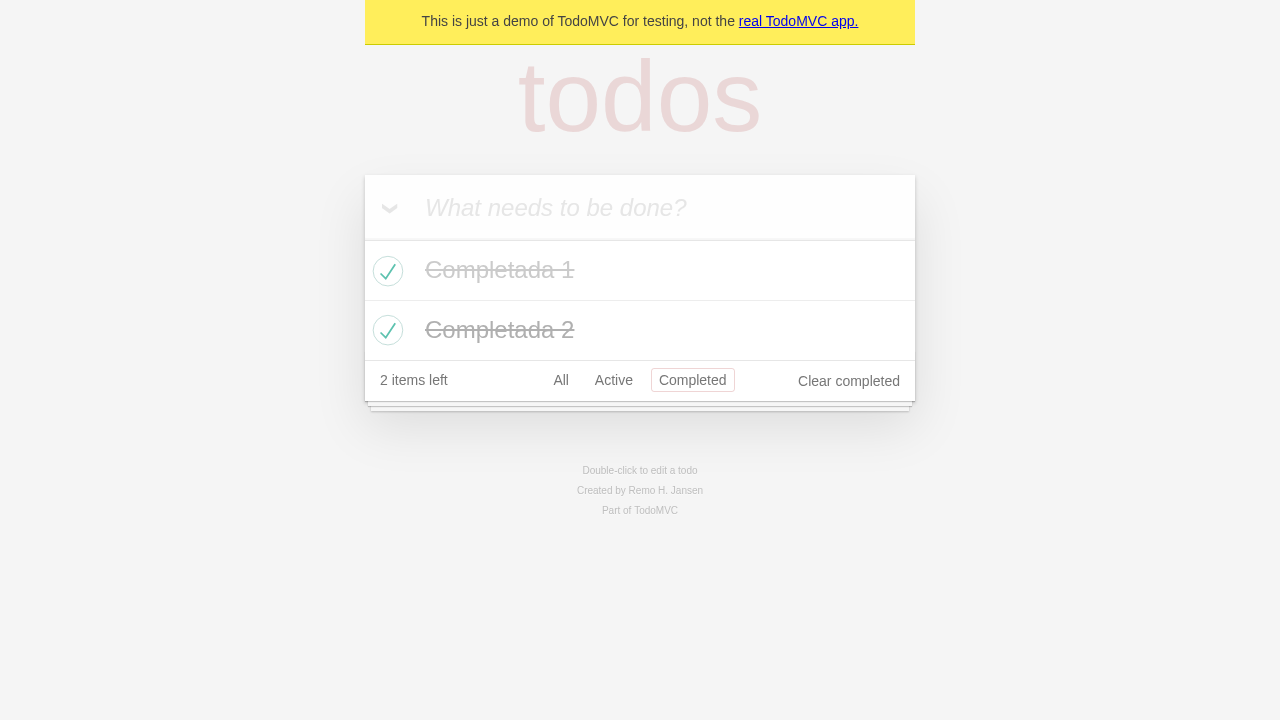


  → test_limpiar_completadas_las_elimina


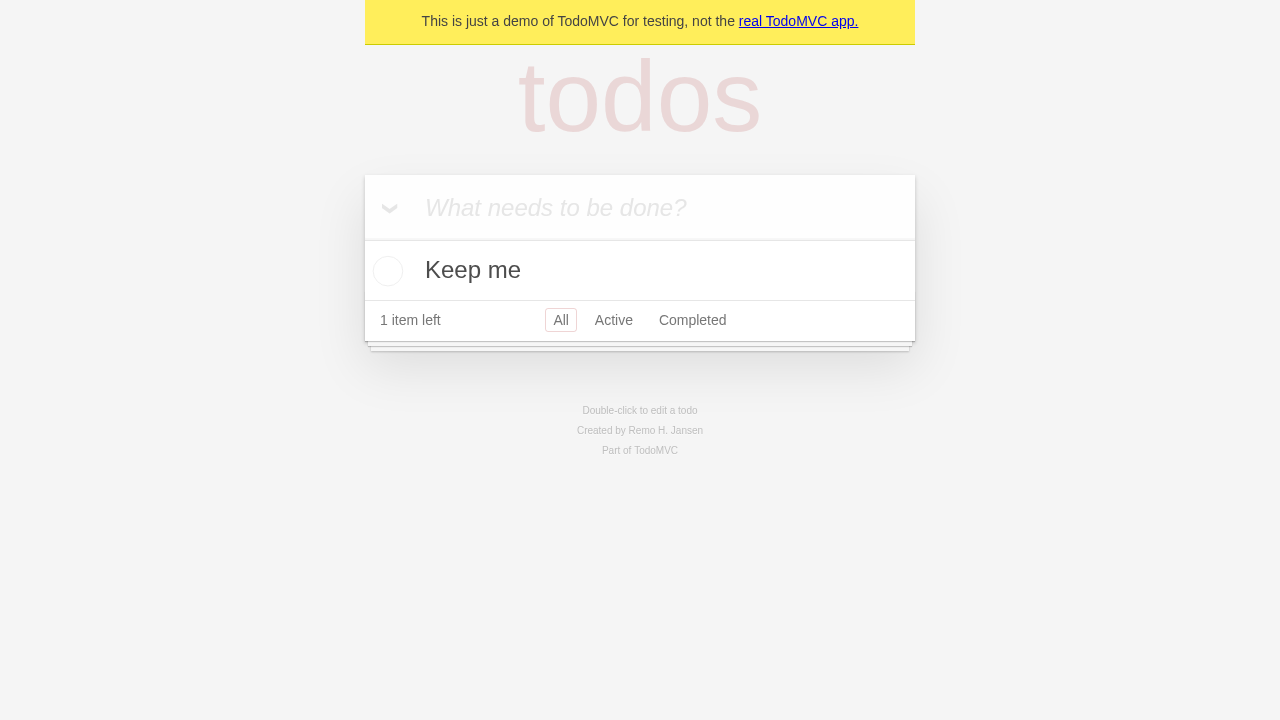

In [ ]:
import asyncio
from playwright.async_api import async_playwright, Page, expect

# ════════════════════════════════════════════════════════════
#  SOLUCIÓN — 5 tests implementados
# ════════════════════════════════════════════════════════════

async def test_app_inicia_vacia(page: Page):
    todo = TodoPage(page)
    await todo.navigate()
    # La lista no debe tener ítems visibles
    await expect(todo.items).to_have_count(0)



async def test_crear_tarea_aparece_en_lista(page: Page):
    todo = TodoPage(page)
    await todo.navigate()
    await todo.agregar_tarea('Estudiar Playwright')
    # La tarea debe aparecer en la lista
    await expect(todo.items).to_have_count(1)
    await expect(page.get_by_text('Estudiar Playwright')).to_be_visible()


async def test_completar_tarea_reduce_contador(page: Page):
    todo = TodoPage(page)
    await todo.navigate()
    await todo.agregar_tareas(['Tarea A', 'Tarea B', 'Tarea C'])
    # Completar la primera tarea
    await todo.completar_tarea('Tarea A')
    # El contador de pendientes debe ser 2
    await expect(todo.contador).to_have_text('2') # Usar expect para auto-retry de Playwright


async def test_filtro_active_oculta_completadas(page: Page):
    todo = TodoPage(page)
    await todo.navigate()
    await todo.agregar_tareas(['Primera', 'Segunda', 'Tercera'])
    await todo.completar_tarea('Primera')
    # Filtrar solo las activas
    await todo.filtrar_activas()
    # Solo deben verse 2 tareas (las no completadas)
    await expect(todo.items).to_have_count(2)
    # La completada no debe verse
    await expect(page.get_by_text('Primera')).not_to_be_visible()


async def test_filtro_completadas_muestra_solo_completadas(page: Page):
    """
    DADO:    tengo 3 tareas y 2 están completadas
    CUANDO:  activo el filtro 'Completed'
    ENTONCES: solo se ven 2 tareas (las completadas)
    """
    todo = TodoPage(page)
    await todo.navigate()
    await todo.agregar_tareas(['Activa 1', 'Completada 1', 'Activa 2', 'Completada 2'])
    await todo.completar_tarea('Completada 1')
    await todo.completar_tarea('Completada 2')

    await todo.filtrar_completadas()

    await expect(todo.items).to_have_count(2)
    await expect(page.get_by_text('Completada 1')).to_be_visible()
    await expect(page.get_by_text('Completada 2')).to_be_visible()
    await expect(page.get_by_text('Activa 1')).not_to_be_visible()
    await expect(page.get_by_text('Activa 2')).not_to_be_visible()


async def test_limpiar_completadas_las_elimina(page: Page):
    todo = TodoPage(page)
    await todo.navigate()
    await todo.agregar_tareas(['Keep me', 'Delete me 1', 'Delete me 2'])

    # Completar las dos últimas
    await todo.completar_tarea('Delete me 1')
    await todo.completar_tarea('Delete me 2')
    # Limpiar completadas
    await todo.limpiar_completadas()
    # Asegurar que se muestra todo para verificar el conteo final
    await todo.filtrar_todas()
    # Solo debe quedar 1 tarea
    await expect(todo.items).to_have_count(1)
    await expect(page.get_by_text('Keep me')).to_be_visible()


# ── Runner ───────────────────────────────────────────────────
todos_los_tests = [
    test_app_inicia_vacia,
    test_crear_tarea_aparece_en_lista,
    test_completar_tarea_reduce_contador,
    test_filtro_active_oculta_completadas,
    test_filtro_completadas_muestra_solo_completadas, # New test added here
    test_limpiar_completadas_las_elimina,
]

resultados = []
screenshots_finales = []

async def run_solution_tests():
    async with async_playwright() as pw:
        browser = await pw.chromium.launch(headless=True)

        for fn in todos_los_tests:
            page = await browser.new_page()
            nombre = fn.__name__
            try:
                # Clear localStorage and reload for a clean state before each test
                await page.goto(TODO_URL)
                await page.evaluate("localStorage.clear();")
                await page.reload()

                await fn(page) # Call the async test function with await
                path = f'/tmp/sol_{nombre}.png'
                await page.screenshot(path=path) # screenshot is async
                screenshots_finales.append((path, nombre))
                resultados.append((nombre, '✅ PASS', None))
            except Exception as e:
                resultados.append((nombre, '❌ FAIL', str(e)[:150]))
            finally:
                await page.close()

        await browser.close()

await run_solution_tests()

# Reporte
print('\n' + '='*60)
print('  SOLUCIÓN — RESULTADOS FINALES')
print('='*60)
for nombre, status, error in resultados:
    print(f'  {status}  {nombre}')
    if error:
        print(f'         └─ {error}')
print('='*60)
print(f'  {sum(1 for _,s,_ in resultados if "PASS" in s)}/{len(resultados)} tests pasaron')
print('='*60)

# Mostrar screenshots de cada test
print('\n📸 Estado final de cada test:')
for path, nombre in screenshots_finales:
    print(f'\n  → {nombre}')
    display(Image(path, width=500))

---

## 📊 Resumen de lo aprendido

| Concepto | Lo que vimos |
|----------|--------------|
| `sync_playwright()` | Contexto para crear el browser y las páginas |
| `page.goto(url)` | Navegar a una URL |
| `get_by_role()`, `get_by_placeholder()` | Locators robustos y semánticos |
| `expect(...).to_have_count()` | Aserciones con auto-retry |
| `fill()`, `press()`, `click()`, `check()` | Acciones sobre elementos |
| `Page Object Model` | Clase que encapsula selectores y acciones |
| Tests independientes | Cada test navega desde cero, sin depender de otro |

---

* Pruebas de Software · 7mo Semestre*